In [26]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive/Colab Notebooks/Zadanie1")


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

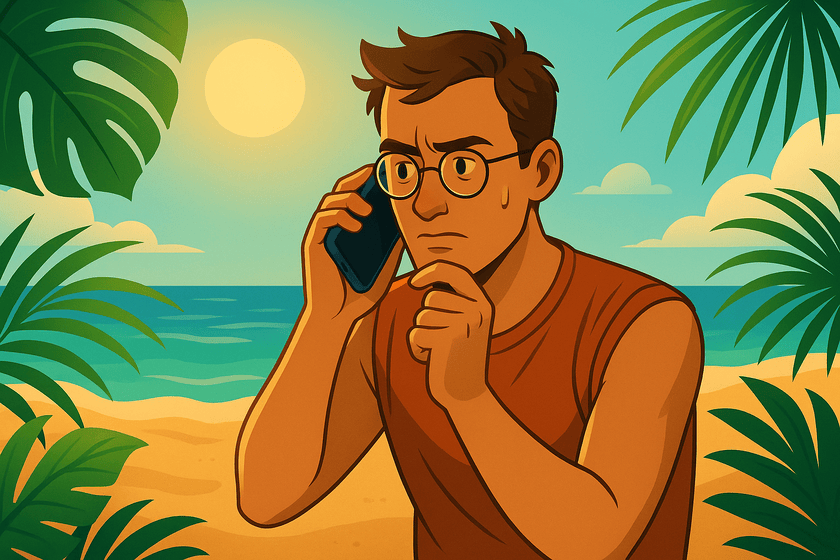

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


Na początku wgrywam dane, robię ich kopię na której będę pracował a następnie sprawdzam gdzie występują braki.

In [28]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
df = titanic_df.copy()
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,98
Cabin,687


Kolejnym krokiem jest usunięcie kolumn, które nie wnoszą bezpośrednio informacji oraz dodatkowo w przypadku 'Cabin' - bardzo dużo brakujących danych. Ponadto uzupełnienie kolumn danymi, na podstawie mediany oraz wartości występującej najczęściej.

In [29]:
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Utworzenie nowych kolumn, wprowadzających dodatkowe dane do analizy.

In [30]:
df['IsAlone'] = (
    (df['SibSp'] == 0) &
    (df['Parch'] == 0)
).astype(int)

df['IsAdultMale'] = (
    (df['Sex'] == 'male') &
    (df['Age'] >= 18)
).astype(int)

Kodowanie danych poprzez zmianę płci na postać binarną oraz dane kategorialne zawierające porty zmienione zostały na nowe kolumny poprzez kodowanie gorąco jedynkowe.

In [31]:
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

In [32]:
df = pd.get_dummies(
    df,
    columns=['Embarked'],
    dtype=int
)

Kolejne sprawdzenie brakujących danych, jak widać wszystkie komórki są uzupełnione.

In [33]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   IsAlone      891 non-null    int64  
 8   IsAdultMale  891 non-null    int64  
 9   Embarked_C   891 non-null    int64  
 10  Embarked_Q   891 non-null    int64  
 11  Embarked_S   891 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 90.5 KB


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
IsAlone,0
IsAdultMale,0
Embarked_C,0


Występowanie potencjalnych wartości odstających w zmiennych liczbowych poddano wizualnej ocenie wykresów pudełkowych. Zidentyfikowane wartości skrajne (outliery) nie zostały usunięte, ponieważ nie wskazują na błędy w danych i mogą reprezentować rzeczywiste obserwacje, ze względu chociażby na to, że ceny mogły obejmować luksuowe bilety.

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

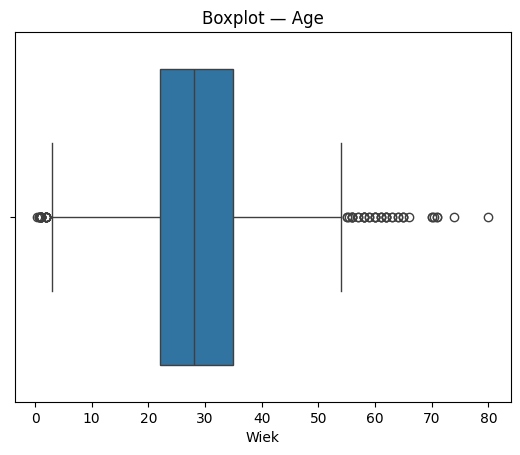

In [52]:
sns.boxplot(x=df['Age'])
plt.title('Boxplot — Age')
plt.xlabel('Wiek')
plt.show()

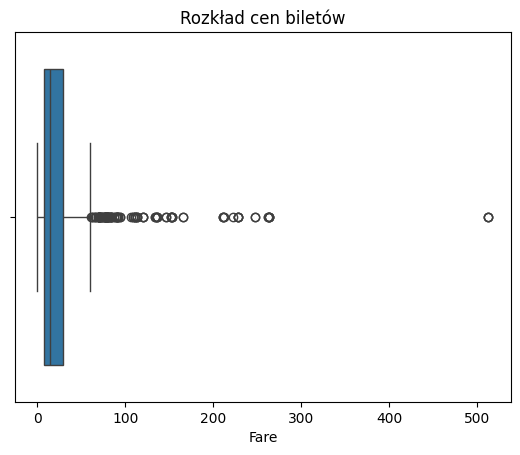

In [51]:
sns.boxplot(x=df['Fare'])
plt.title('Rozkład cen biletów')
plt.xlabel('Fare')
plt.show()

Widoczna jest wyraźna różnica w przeżywalności kobiet i mężczyzn. Kobiety stanowiły znacznie większą część osób, które przeżyły, co wskazuje na silną zależność pomiędzy płcią a przeżyciem.

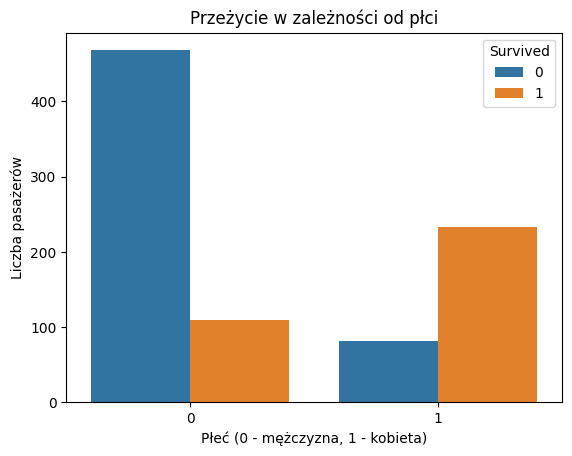

In [40]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Przeżycie w zależności od płci')
plt.xlabel('Płeć (0 - mężczyzna, 1 - kobieta)')
plt.ylabel('Liczba pasażerów')
plt.show()

Pasażerowie pierwszej klasy mieli wyraźnie większy udział osób, które przeżyły, podczas gdy w trzeciej klasie przeważały osoby, które zginęły.

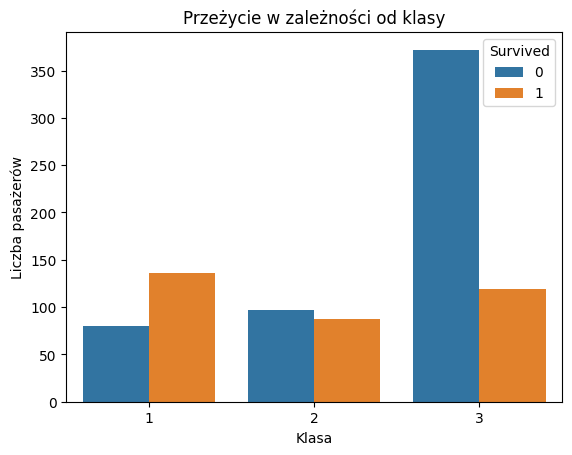

In [41]:
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Przeżycie w zależności od klasy')
plt.xlabel('Klasa')
plt.ylabel('Liczba pasażerów')
plt.show()

Jest to uogólnienie kolumn opisujących liczbę krewnych (rodziców, rodzeństwa, małżonków, dzieci) na pokładzie i wskazuje przewagę przeżywalności osób podróżójących z rodziną.

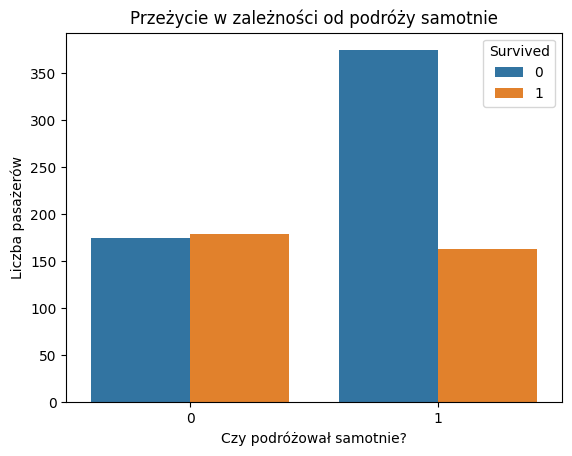

In [42]:
sns.countplot(data=df, x='IsAlone', hue='Survived')
plt.title('Przeżycie w zależności od podróży samotnie')
plt.xlabel('Czy podróżował samotnie?')
plt.ylabel('Liczba pasażerów')
plt.show()

Wykres ten wskazuje, że jeszcze większy wpływ na przeżycie miało to czy osoba była dorosłym mężczyzną, ze względu na pierwszeństwo dzieci w ewakuacji, wykres przedstawia dogłębniej zależność płci.

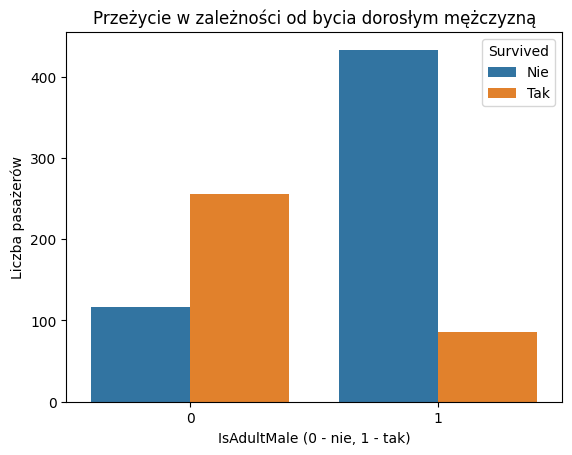

In [54]:
sns.countplot(data=df, x='IsAdultMale', hue='Survived')
plt.title('Przeżycie w zależności od bycia dorosłym mężczyzną')
plt.xlabel('IsAdultMale (0 - nie, 1 - tak)')
plt.ylabel('Liczba pasażerów')
plt.legend(title='Survived', labels=['Nie', 'Tak'])
plt.show()

Wkazuje ewidentną przewagę w przeżywalności dzieci.

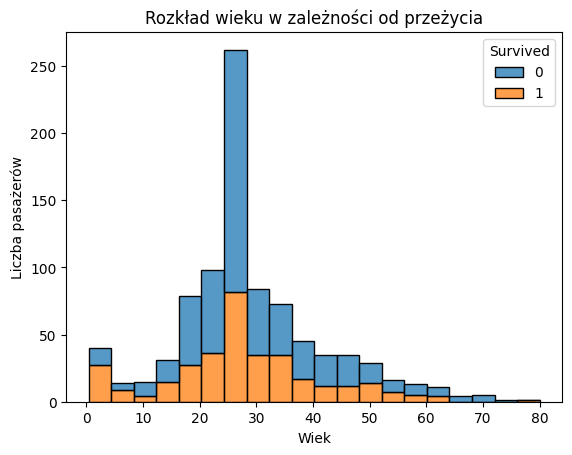

In [44]:
sns.histplot(
    data=df,
    x='Age',
    hue='Survived',
    bins=20,
    multiple='stack'
)

plt.title('Rozkład wieku w zależności od przeżycia')
plt.xlabel('Wiek')
plt.ylabel('Liczba pasażerów')
plt.show()

Widać, że cena biletu miała wpływ na zwiększenie szans na przeżycie.

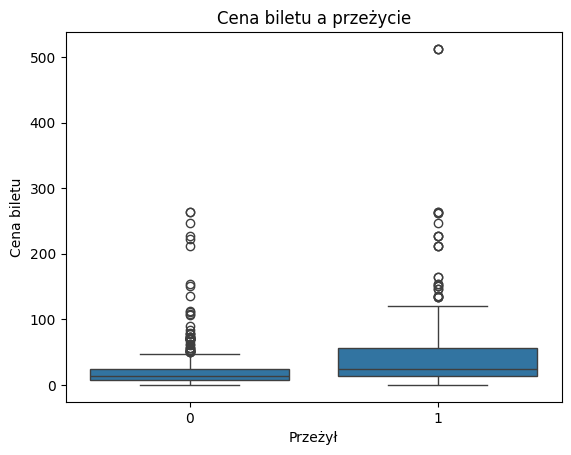

In [45]:
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Cena biletu a przeżycie')
plt.xlabel('Przeżył')
plt.ylabel('Cena biletu')
plt.show()